<a href="https://colab.research.google.com/github/genaiconference/Agentic_KAG_Workshop_DHS_2026/blob/main/01_construct_knowledge_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Knowledge Graph Builder - Movies Knowledge Graph
## End-to-End `neo4j-graphrag` Pipeline

This notebook builds a movie knowledge graph from the **TMDB + IMDb Merged Movies Dataset** using the **fully-componentised `neo4j_graphrag` `Pipeline`**


In [ ]:
!git clone https://github.com/genaiconference/Agentic_KAG_Workshop_DHS_2026.git

Cloning into 'Agentic_KAG_Workshop_DHS_2026'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 23 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 1.96 MiB | 4.45 MiB/s, done.
Resolving deltas: 100% (8/8), done.


## Install Required Packages

In [ ]:
# Run once per environment. Comment out after the first successful install.
%pip install --quiet -r /content/Agentic_KAG_Workshop_DHS_2026/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.7/263.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 110.1 MB/s eta 0:00:00


## Credentials & Drivers

We use Neo4j Free sandbox instance and OpenAI key. Load credentials from .env

In [ ]:
import os

os.chdir('/content/Agentic_KAG_Workshop_DHS_2026/')

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    print("error reading env details")
    pass

# --- Neo4j Sandbox ---
NEO4J_URI      = os.getenv('NEO4J_URI')
NEO4J_USERNAME = os.getenv('NEO4J_USERNAME')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = os.getenv('NEO4J_DATABASE')

# --- OpenAI ---
os.environ.setdefault(
    'OPENAI_API_KEY',
    os.getenv('OPENAI_API_KEY')
)

print('NEO4J_URI :', NEO4J_URI)
print('OPENAI key set:', bool(os.environ.get('OPENAI_API_KEY')))

NEO4J_URI : bolt://32.192.25.99
OPENAI key set: True


In [ ]:
from neo4j import GraphDatabase

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
driver.verify_connectivity()
print('Connected to Neo4j ✔')

Connected to Neo4j ✔


## Initialize LLM & Embedder

Two `OpenAILLM` instances (one for extraction, one for strict JSON outputs) plus an `OpenAIEmbeddings` instance.

In [ ]:
from neo4j_graphrag.llm import OpenAILLM
from neo4j_graphrag.embeddings import OpenAIEmbeddings

# Main LLM used by LLMEntityRelationExtractor
llm = OpenAILLM(
    model_name='gpt-4o',
)

# Strict-JSON LLM (handy for schema extraction or community summarisation)
json_llm = OpenAILLM(
    model_name='gpt-4o',
    model_params={
        'response_format': {'type': 'json_object'},
    },
)

embedder = OpenAIEmbeddings(model='text-embedding-3-small')
print('LLM + embedder ready ✔')

LLM + embedder ready ✔


## Pipeline Structure

A Knowledge Graph (KG) construction pipeline requires a few components. Below are the 8 components.

1. **Data loader** – custom loader that reads the movies CSV and emits a `PdfDocument` wrapping a list of per-movie dicts.
2. **Text splitter** – custom splitter that turns each movie row into a `TextChunk` with metadata (title, release_date, dataset).
3. **Chunk embedder** – embeds each chunk text with OpenAI embeddings.
4. **Schema builder** – manual `NodeType` / `RelationshipType` / `patterns` for the movie domain (Movie, Person, Genre, ProductionCompany, Country, Language, Keyword, CastMember). Schema can be provided manually or extracted automatically using LLMs.
5. **Entity & relation extractor** – `LLMEntityRelationExtractor` grounded by the schema. Extract relevant entities and relations from the text.
6. **Graph pruner:** clean the graph based on schema, if provided.
6. **KG writer** – `Neo4jWriter` persists the extracted graph to Neo4J Sandbox. save the identified entities and relations.
7. **Entity resolver** – `SinglePropertyExactMatchResolver` merge similar entities into a single node.
8. **Entity embedder** (custom `Component`) – embeds the longest string property of each entity.

**Pipeline assembly** – `Pipeline().add_component(...)` + `pipe.connect(...)` + `await pipe.run(...)`.

**Validation Cypher queries** – sanity checks against the new movie schema (`CAST_IN`, `DIRECTED_BY`, `HAS_GENRE`, …).

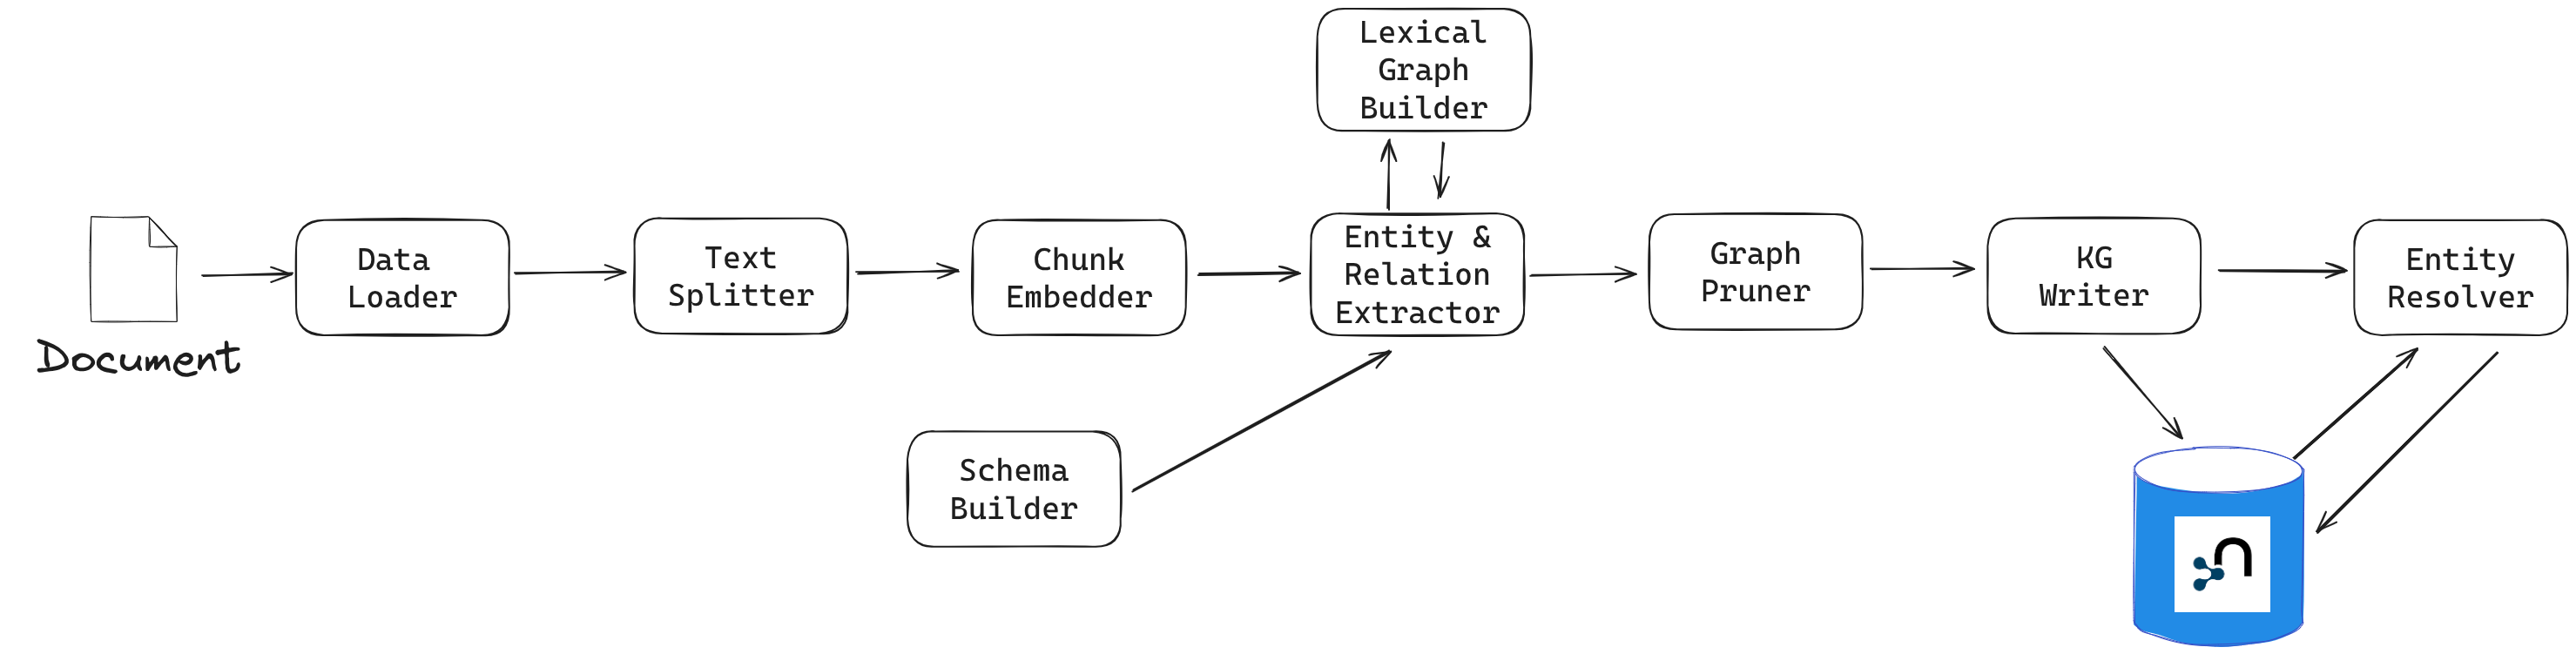

# Creating Components to Build Knowledge Graph
Components are asynchronous units of work that perform simple tasks, such as chunking documents or saving results to Neo4j. This package includes a few default components, but developers can create their own custom components as well.

## 1. Data Loader

Data loaders start from a file path and return the text extracted from the input file.

This module reads the TMDB+IMDb CSV, filters to movies released after the year 2000, and returns a single `PdfDocument` whose `text` is a string representation of a list of per-movie dicts.

In [ ]:
from pathlib import Path
import pandas as pd
import math
import os
import json
import ast
from neo4j_graphrag.experimental.components.data_loader import DataLoader
from neo4j_graphrag.experimental.components.types import LoadedDocument

excel_path = os.getenv('MOVIES_CSV_PATH')

DATA_PATH = Path(excel_path)

class MoviesDataLoader(DataLoader):
    """Custom DataLoader that reads a movies CSV and returns a PdfDocument.

    The `text` field of the returned PdfDocument is a `repr()` of a list of
    per-movie dicts. The splitter (next step) will `ast.literal_eval` it.
    """

    def __init__(self, **kwargs):

        pass

    async def run(self, path: Path) -> LoadedDocument:
        # Changed from pd.read_csv to pd.read_excel
        df = pd.read_excel(path)
        print(f"Initial DataFrame shape: {df.shape}")


        df = df.reset_index(drop=True)
        print(f"Final DataFrame shape after reset_index: {df.shape}")

        # Build a list of per-movie dicts
        # Convert all values to appropriate types, including handling NaT for dates
        records = []
        for _, row in df.iterrows():
            record_dict = {}
            for key, value in row.items():
                if pd.isna(value):
                    record_dict[key] = None
                elif isinstance(value, pd.Timestamp):
                    record_dict[key] = value.strftime('%Y-%m-%d')
                else:
                    record_dict[key] = value
            records.append(record_dict)

        print(f'Loaded {len(records)} movie rows from {path.name} (no filtering applied).')

        return LoadedDocument(
            text=repr(records),
            document_info={'path': str(path)},
        )


# Execute
# loader = MoviesDataLoader()
# page_data = await loader.run(DATA_PATH)
# print('Document text length:', len(page_data.text))

## 2. Custom Text Splitter

Decodes the `Document` produced by the loader and turns each movie record into a `TextChunk` with rich metadata. The chunk `text` is a human/LLM-friendly multi-line summary of the movie

In [ ]:
import ast
from neo4j_graphrag.experimental.components.text_splitters.base import TextSplitter
from neo4j_graphrag.experimental.components.types import TextChunks, TextChunk, LoadedDocument

def _row_to_movie_doc(rec: dict) -> str:
    """Build a multi-line, LLM-friendly text block for a single movie row."""
    lines = []
    lines.append(f"Title: {rec.get('title','')}")
    if rec.get('release_date'):  lines.append(f"Release date: {rec['release_date']}")
    if rec.get('runtime'):       lines.append(f"Runtime (minutes): {rec['runtime']}")
    if rec.get('budget'):        lines.append(f"Budget (USD): {rec['budget']}")
    if rec.get('revenue'):       lines.append(f"Revenue (USD): {rec['revenue']}")
    if rec.get('vote_average'):  lines.append(f"Vote average: {rec['vote_average']}")
    if rec.get('genres'):                lines.append(f"Genres: {rec['genres']}")
    if rec.get('production_companies'):  lines.append(f"Production companies: {rec['production_companies']}")
    if rec.get('production_countries'):  lines.append(f"Production countries: {rec['production_countries']}")
    if rec.get('spoken_languages'):      lines.append(f"Spoken languages: {rec['spoken_languages']}")
    if rec.get('keywords'):              lines.append(f"Keywords: {rec['keywords']}")
    if rec.get('directors'):             lines.append(f"Director(s): {rec['directors']}")
    if rec.get('cast'):                  lines.append(f"Cast: {rec['cast']}")
    if rec.get('tagline'):               lines.append(f"Tagline: {rec['tagline']}")
    if rec.get('overview'):              lines.append(f"Overview: {rec['overview']}")
    return '\n'.join(lines)


class MoviesRowTextSplitter(TextSplitter):
    """Split the loader's PdfDocument into one TextChunk per movie row."""

    def __init__(self, dataset_name: str = 'TMDB+IMDb Movies'):
        self.dataset_name = dataset_name

    async def run(self, page_data: LoadedDocument) -> TextChunks:
        raw = page_data['text'] if isinstance(page_data, dict) else page_data.text
        records = ast.literal_eval(raw)

        chunks = []
        for i, rec in enumerate(records):
            chunks.append(TextChunk(
                index=i,
                text=_row_to_movie_doc(rec),
                metadata={
                    'title':        rec.get('title', ''),
                    'release_date': rec.get('release_date', ''),
                    'dataset':      self.dataset_name,
                },
            ))
        print(f'Built {len(chunks)} TextChunks (one per movie).')
        return TextChunks(chunks=chunks)


# Execute
# splitter = MoviesRowTextSplitter()
# text_chunks = await splitter.run(page_data)
# print('First chunk preview:\n', text_chunks.chunks[0].text[:500])

In [ ]:
text_chunks.chunks[0]

## 3. Chunk Embedder

Adds an embedding to every chunk so we can later run vector search against the movie documents.

In [ ]:
from neo4j_graphrag.experimental.components.embedder import TextChunkEmbedder

text_chunk_embedder = TextChunkEmbedder(embedder=embedder)

# Execute
embedded_chunks = await text_chunk_embedder.run(text_chunks=text_chunks)
print('Embedded chunks:', len(embedded_chunks.chunks))
print('First chunk embedding length:', len(embedded_chunks.chunks[0].metadata.get('embedding', [])))

In [ ]:
# import pickle

# output_path = '/content/drive/MyDrive/embedded_chunks.pkl'
# with open(output_path, 'wb') as f:
#     pickle.dump(embedded_chunks, f)

# print(f'Embedded chunks saved to {output_path}')

In [ ]:
import pickle

output_path = '/content/drive/MyDrive/embedded_chunks.pkl'
with open(output_path, 'rb') as f:
    loaded_embedded_chunks = pickle.load(f)

print(f'Embedded chunks loaded from {output_path}')

print('Embedded chunks:', len(loaded_embedded_chunks.chunks))
print('First chunk embedding length:', len(loaded_embedded_chunks.chunks[0].metadata.get('embedding', [])))

## 6. Schema (manual)


**Nodes**: Movie · Person · Genre · ProductionCompany · Country · Language · Keyword · CastMember  
**Relationships**: HAS_GENRE · PRODUCED_BY · PRODUCED_IN · SPOKEN_IN · TAGGED_WITH · DIRECTED_BY · WRITTEN_BY · CAST_IN

Patterns describe `(source) -[REL]-> (target)` triplets and are used both by the extractor (to constrain the LLM) and by the graph pruner (to discard out-of-schema edges).

In [ ]:
from neo4j_graphrag.experimental.components.schema import (
    SchemaBuilder,
    NodeType,
    RelationshipType,
    GraphSchema,
)

schema_builder = SchemaBuilder()

# -------- Node Types --------
node_types = [
    NodeType(
        label='Movie',
        description='A motion picture / film with metadata such as title, runtime, budget, revenue, release date and ratings.',
        properties=[
            {'name': 'title',         'type': 'STRING',  'description': 'Title of the movie.'},
            {'name': 'release_date',  'type': 'DATE',    'description': 'Theatrical release date (YYYY-MM-DD).'},
            {'name': 'runtime_minutes',       'type': 'INTEGER', 'description': 'Runtime in minutes.'},
            {'name': 'budget_usd',        'type': 'INTEGER', 'description': 'Production budget in USD.'},
            {'name': 'revenue_usd',       'type': 'INTEGER', 'description': 'Worldwide box-office revenue in USD.'},
            {'name': 'vote_average',  'type': 'FLOAT',   'description': 'Average user rating (typically 0–10).'},
            {'name': 'overview',      'type': 'STRING',  'description': 'Plot synopsis.'},
            {'name': 'tagline',       'type': 'STRING',  'description': 'Marketing tagline of the movie.'},
        ],
        additional_properties=True,
    ),
    NodeType(
        label='Person',
        description='A real person involved in a movie as director, writer, actor or other crew.',
        properties=[
            {'name': 'name', 'type': 'STRING', 'description': 'Full name of the person.'},
        ],
        additional_properties=True,
    ),
    NodeType(
        label='Genre',
        description='A film genre such as Action, Drama, Comedy, Horror, Science Fiction.',
        properties=[
            {'name': 'name', 'type': 'STRING', 'description': 'Canonical genre name.'},
        ],
        additional_properties=True,
    ),
    NodeType(
        label='ProductionCompany',
        description='A company that produced or financed the movie.',
        properties=[
            {'name': 'name', 'type': 'STRING', 'description': 'Name of the production company.'},
        ],
        additional_properties=True,
    ),
    NodeType(
        label='Country',
        description='A country where the movie was produced.',
        properties=[
            {'name': 'name', 'type': 'STRING', 'description': 'Country name.'},
        ],
        additional_properties=True,
    ),
    NodeType(
        label='Language',
        description='A spoken language in the movie.',
        properties=[
            {'name': 'name', 'type': 'STRING', 'description': 'Language name (e.g. English, French).'},
        ],
        additional_properties=True,
    ),
    NodeType(
        label='Keyword',
        description='A descriptive tag / theme attached to the movie (e.g. "time travel", "heist").',
        properties=[
            {'name': 'name', 'type': 'STRING', 'description': 'Keyword text.'},
        ],
        additional_properties=True,
    ),
    NodeType(
        label='CastMember',
        description='A character portrayed in the movie (distinct from the real Person who plays it).',
        properties=[
            {'name': 'name', 'type': 'STRING', 'description': 'Character name.'},
        ],
        additional_properties=True,
    ),
]

# -------- Relationship Types --------
relationship_types = [
    RelationshipType(label='HAS_GENRE',  description='Movie -[HAS_GENRE]-> Genre',                 properties=[], additional_properties=True),
    RelationshipType(label='PRODUCED_BY',description='Movie -[PRODUCED_BY]-> ProductionCompany',   properties=[], additional_properties=True),
    RelationshipType(label='PRODUCED_IN',description='Movie -[PRODUCED_IN]-> Country',             properties=[], additional_properties=True),
    RelationshipType(label='SPOKEN_IN',  description='Movie -[SPOKEN_IN]-> Language',              properties=[], additional_properties=True),
    RelationshipType(label='TAGGED_WITH',description='Movie -[TAGGED_WITH]-> Keyword',             properties=[], additional_properties=True),
    RelationshipType(label='DIRECTED_BY',description='Movie -[DIRECTED_BY]-> Person (director)',   properties=[], additional_properties=True),
    RelationshipType(label='WRITTEN_BY', description='Movie -[WRITTEN_BY]-> Person (writer)',      properties=[], additional_properties=True),
    RelationshipType(label='CAST_IN',    description='Person -[CAST_IN]-> Movie (actor appears in movie)', properties=[], additional_properties=True),
]

# -------- Patterns (allowed triplets) --------
patterns = [
    ('Movie',  'HAS_GENRE',   'Genre'),
    ('Movie',  'PRODUCED_BY', 'ProductionCompany'),
    ('Movie',  'PRODUCED_IN', 'Country'),
    ('Movie',  'SPOKEN_IN',   'Language'),
    ('Movie',  'TAGGED_WITH', 'Keyword'),
    ('Movie',  'DIRECTED_BY', 'Person'),
    ('Movie',  'WRITTEN_BY',  'Person'),
    ('Person', 'CAST_IN',     'Movie'),
]

manual_schema = GraphSchema(
    node_types=node_types,
    relationship_types=relationship_types,
    patterns=patterns,
)

print('Schema ready:')
print('  node_types        :', [n.label for n in node_types])
print('  relationship_types:', [r.label for r in relationship_types])
print('  patterns          :', len(patterns))

## Schema (extracted)

In [ ]:
from neo4j_graphrag.experimental.components.schema import SchemaFromTextExtractor
from neo4j_graphrag.llm import OpenAILLM

# Instantiate the automatic schema extractor component
schema_extractor = SchemaFromTextExtractor(
    llm=OpenAILLM(
        model_name="gpt-5-mini",
        model_params={
            #"max_tokens": 2000,
            "response_format": {"type": "json_object"},
        },
    )
)
# Slice only the first 1000 text chunks to avoid rate limit issues
full_text = "\n\n".join(chunk.text for chunk in text_chunks.chunks[:1000])
# Extract the schema from the text
extracted_schema = await schema_extractor.run(text=full_text)

In [ ]:
print('--- Extracted Schema ---')

print('\nNode Types:')
for node_type in extracted_schema.node_types:
    print(f"  - Label: {node_type.label}")
    if node_type.properties:
        print('    Properties:')
        for prop in node_type.properties:
            print(f"      - Name: {prop.name}, Type: {prop.type}")

print('\nRelationship Types:')
for rel_type in extracted_schema.relationship_types:
    print(f"  - Label: {rel_type.label}")

print('\nPatterns:')
for pattern in extracted_schema.patterns:
    print(f"  - ({pattern.source})-[:{pattern.relationship}]->({pattern.target})")

## Schema Visualization

In [ ]:
from neo4j_graphrag.experimental.utils.schema import schema_visualization
VG = schema_visualization(manual_schema)
html = VG.render()

# in Jupyter:
display(html)

# to save the generated HTML
with open("my_schema.html", "w") as f:
    f.write(html.data)

## 7. Entity & Relation Extractor

Uses `LLMEntityRelationExtractor`. The schema we built above is passed in via the pipeline; here we just configure the extractor itself.

In [ ]:
ENTITY_RELATION_EXTRACTOR_PROMPT = """
You are an elite AI model trained to extract structured data to construct a knowledge graph.

Your task is to:
1. Extract **entities (nodes)** from the given input text.
2. Assign a **type (label)** to each entity (based on context).
3. Extract **relationships** between the nodes. The relationship direction goes from the start node to the end node.
4. Return everything in strict **JSON** format.


**✅ Output Format (Strict JSON):**

Return result as JSON using the following format:
{{"nodes": [ {{"id": "0", "label": "the type of entity", "properties": {{"name": "name of entity" }} }}],
  "relationships": [{{"type": "TYPE_OF_RELATIONSHIP", "start_node_id": "0", "end_node_id": "1", "properties": {{"details": "Description of the relationship"}} }}] }}


- Use only the information from the Input text. Do not add any additional information.
- If the input text is empty, return empty Json.
- Make sure to create as many nodes and relationships as needed to offer rich context.
- An AI knowledge assistant must be able to read this graph and immediately understand the context.

Use only the following nodes and relationships (if provided):
{schema}

- Assign a unique string ID (e.g., "0", "1", "2", ...) to each node, and reuse it to define relationships.
- Relationship direction must be logical and context-driven.
- Do not include explanations, markdown, or non-JSON text.
- Ensure double quotes around all JSON property keys/values.
- Do NOT wrap the JSON in backticks or a list.

---
**Example:**

Input text:
"Bob joined Acme Corp as a Data Scientist in 2022."

Output:
{{
  "nodes": [
    {{"id": "0", "label": "Person", "properties": {{"name": "Bob"}}}},
    {{"id": "1", "label": "Organization", "properties": {{"name": "Acme Corp"}}}}
  ],
  "relationships": [
    {{"type": "WORKS_AT", "start_node_id": "0", "end_node_id": "1", "properties": {{"role": "Data Scientist", "since": "2022"}}}}
  ]
}}

---
Input text:

{text}
"""

In [ ]:
from neo4j_graphrag.experimental.components.entity_relation_extractor import (
    LLMEntityRelationExtractor,
    OnError,
)
from neo4j_graphrag.experimental.components.types import TextChunks

entity_extractor = LLMEntityRelationExtractor(
    llm=llm,
    on_error=OnError.WARN, # Changed from OnError.RAISE
    create_lexical_graph=False,
    prompt_template=ENTITY_RELATION_EXTRACTOR_PROMPT,
)

# Execute
result = await pipe.run(pipe_inputs)
print('\nPipeline finished ✔')
print(result)

In [ ]:
# # to dump entity graph into pickle

# import pickle

# # Define the filename for the pickle file
# output_filename = "/content/drive/MyDrive/entity_graph.pkl"

# # Save the entity_graph object to the pickle file
# with open(output_filename, "wb") as f:
#     pickle.dump(entity_graph, f)

# print(f"Entity graph saved to {output_filename}")

In [ ]:
import pickle
import os

output_filename = "/content/Agentic_KAG_Workshop_DHS_2026/entity_graph.pkl"

if os.path.exists(output_filename):
    with open(output_filename, "rb") as f:
        entity_graph = pickle.load(f)
    print(f"Entity graph loaded from {output_filename}")
else:
    print(f"No entity graph found at {output_filename}. Please ensure it has been saved.")

Entity graph loaded from /content/Agentic_KAG_Workshop_DHS_2026/entity_graph.pkl


## 8. KG Writer (Neo4jWriter)

Persists the extracted graph into neo4j sandbox.

In [ ]:
from neo4j_graphrag.experimental.components.kg_writer import Neo4jWriter

eg_writer = Neo4jWriter(
    driver=driver,
    neo4j_database=NEO4J_DATABASE,
    batch_size=1000,
)
print('Neo4jWriter ready ✔')

result = await eg_writer.run(graph=entity_graph)

Neo4jWriter ready ✔


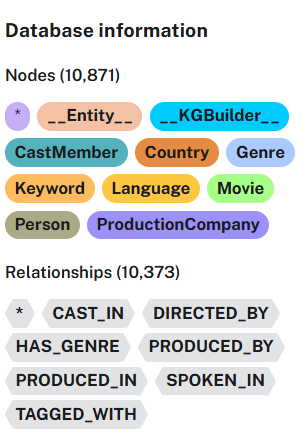

## 9. Entity Resolver

We use exact-match resolution on the most discriminating string property of each node label:
* `Movie` nodes share `title`
* All other `__Entity__` nodes (Person, Genre, …) share `name`

We run the resolver twice — once on `title`, once on `name` — so that both axes are deduplicated.

In [ ]:
from neo4j_graphrag.experimental.components.resolver import SinglePropertyExactMatchResolver

# The SinglePropertyExactMatchResolver performs entity resolution based on the specified 'resolve_property'.
# Here, 'resolver_title' will resolve entities based on their 'title' property.
resolver_title = SinglePropertyExactMatchResolver(driver=driver, resolve_property='title')
res_exactmatch = await resolver_title.run()


In [ ]:
# And 'resolver_name' will resolve entities based on their 'name' property.
resolver_name  = SinglePropertyExactMatchResolver(driver=driver, resolve_property='name')
res_exactmatch = await resolver_name.run()

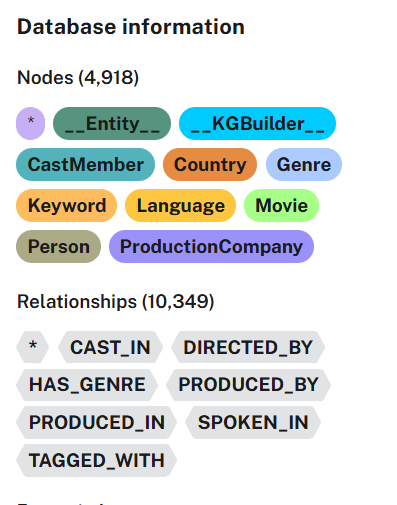

### Check for duplicate nodes after resolution

These queries will help identify if any nodes with the same 'title' (for Movies) or 'name' (for other entities) still exist, indicating if the resolvers successfully merged duplicates or if there were no duplicates to begin with.

In [ ]:
import pandas as pd

def run_cypher(query: str, **params) -> pd.DataFrame:
    with driver.session(database=NEO4J_DATABASE) as session:
        res = session.run(query, **params)
        return pd.DataFrame([r.data() for r in res])

In [ ]:
print('Checking for duplicate Movie nodes by title:')
duplicate_movies = run_cypher('''
MATCH (m:Movie)
WITH m.title AS movieTitle, count(m) AS count, collect(m) AS movies
WHERE count > 1
RETURN movieTitle, count, [n IN movies | elementId(n)] AS duplicateNodeIds
ORDER BY count DESC, movieTitle
''')
display(duplicate_movies)

if duplicate_movies.empty:
    print('No duplicate Movie nodes found by title.')
else:
    print('Duplicate Movie nodes found by title.')

Checking for duplicate Movie nodes by title:


""


No duplicate Movie nodes found by title.


In [ ]:
print('\nChecking for duplicate Person, Genre, ProductionCompany, Country, Language, Keyword, CastMember nodes by name:')
duplicate_entities_by_name = run_cypher('''
MATCH (n)
WHERE n.name IS NOT NULL AND NOT n:Movie // Exclude Movie nodes as they are checked by title
UNWIND labels(n) AS label
WITH label, n.name AS entityName, count(n) AS count, collect(n) AS entities
WHERE count > 1
RETURN label, entityName, count, [e IN entities | elementId(e)] AS duplicateNodeIds
ORDER BY label, count DESC, entityName
''')
display(duplicate_entities_by_name)

if duplicate_entities_by_name.empty:
    print('No duplicate Person, Genre, ProductionCompany, Country, Language, Keyword, CastMember nodes found by name.')
else:
    print('Duplicate Person, Genre, ProductionCompany, Country, Language, Keyword, CastMember nodes found by name.')


Checking for duplicate Person, Genre, ProductionCompany, Country, Language, Keyword, CastMember nodes by name:


""


No duplicate Person, Genre, ProductionCompany, Country, Language, Keyword, CastMember nodes found by name.


## 10. Custom Component — Entity Text Embedder

For every `__Entity__` node, find the **longest string property** and embed it. The embedding is stored on the node as `e.embedding`, enabling later vector search at the entity level (in addition to chunk-level vectors created by step 5).

This is the **exact same pattern** as `EntityTextEmbedder` from the reference notebook.

In [ ]:
from neo4j_graphrag.experimental.pipeline import Component, DataModel

class EmbedEntityResult(DataModel):
    updated_count: int


class EntityTextEmbedder(Component):
    """For every `:__Entity__` node, embed its longest string property → e.embedding."""

    def __init__(self, driver, label: str = '__Entity__', embedder=None):
        self.driver = driver
        self.label = label
        self.embedder = embedder

    async def run(self) -> EmbedEntityResult:
        updated = 0
        with self.driver.session(database=NEO4J_DATABASE) as session:
            result = session.run(
                f'MATCH (e:`{self.label}`) RETURN elementId(e) AS id, properties(e) AS props'
            )
            for record in result:
                node_id = record['id']
                props = record['props'] or {}
                str_props = {k: v for k, v in props.items() if isinstance(v, str) and v.strip()}
                if not str_props:
                    continue
                _, text = max(str_props.items(), key=lambda kv: len(kv[1]))
                emb = self.embedder.embed_query(text)
                session.run(
                    'MATCH (e) WHERE elementId(e) = $id SET e.embedding = $embedding',
                    id=node_id, embedding=emb,
                )
                updated += 1
        print(f'Embedded {updated} entity nodes.')
        return EmbedEntityResult(updated_count=updated)


entity_embedder = EntityTextEmbedder(driver=driver, embedder=embedder)
print('EntityTextEmbedder ready ✔')
result = await entity_embedder.run()

EntityTextEmbedder ready ✔
Embedded 4918 entity nodes.


## 11. Assemble & run the custom Pipeline

This is the heart of the notebook: components are wired explicitly with `pipe.connect(...)`. The data flow is:

```
data_loader → text_splitter → chunk_embedder ─┐
                            schema_builder ───┤→ entity_extractor → eg_writer ┬→ resolver_title
                                                                              ├→ resolver_name
                                                                              └→ entity_embedder
```

The `input_config` mapping on each `connect()` call tells the downstream component which upstream output to consume.

In [ ]:
from neo4j_graphrag.experimental.pipeline import Pipeline

pipe = Pipeline()

# 1. Register components
pipe.add_component(loader,              'data_loader')
pipe.add_component(splitter,            'text_splitter')
pipe.add_component(text_chunk_embedder, 'chunk_embedder')
pipe.add_component(schema_builder,      'schema')
pipe.add_component(entity_extractor,    'entity_extractor')
pipe.add_component(eg_writer,           'eg_writer')
pipe.add_component(resolver_title,      'resolver_title')
pipe.add_component(resolver_name,       'resolver_name')
pipe.add_component(entity_embedder,     'entity_embedder')

# 2. Wire data flow
pipe.connect('data_loader',    'text_splitter',    input_config={'page_data':   'data_loader'})
pipe.connect('text_splitter',  'chunk_embedder',   input_config={'text_chunks': 'text_splitter'})
pipe.connect('chunk_embedder', 'entity_extractor', input_config={'chunks':      'chunk_embedder'})
pipe.connect('schema',         'entity_extractor', input_config={'schema':      'schema'})
pipe.connect('entity_extractor','eg_writer',       input_config={'graph':       'entity_extractor'})

# Post-write components — they operate directly on the DB, so no input mapping is needed
pipe.connect('eg_writer', 'resolver_title',  {})
pipe.connect('eg_writer', 'resolver_name',   {})
pipe.connect('eg_writer', 'entity_embedder', {})

# 3. Inputs that don't come from upstream components
pipe_inputs = {
    'data_loader': {'path': DATA_PATH},
    'schema': {
        'node_types':         node_types,
        'relationship_types': relationship_types,
        'patterns':           patterns,
    },
}

# 4. Run!
# result = await pipe.run(pipe_inputs)
# print('\nPipeline finished ✔')
# print(result)

## 12. Validation Cypher — check the new movie schema landed correctly

In [20]:
# Node-label distribution
run_cypher('''
MATCH (n)
UNWIND labels(n) AS lbl
RETURN lbl AS label, count(*) AS count
ORDER BY count DESC
''')

,label,count
0,__KGBuilder__,4918
1,__Entity__,4918
2,Person,2860
3,Keyword,943
4,ProductionCompany,527
5,Movie,496
6,Language,38
7,Country,27
8,Genre,19
9,CastMember,8


In [21]:
# Relationship-type distribution
run_cypher('''
MATCH ()-[r]->()
RETURN type(r) AS relationshipType, count(*) AS count
ORDER BY count DESC
''')

,relationshipType,count
0,CAST_IN,4744
1,TAGGED_WITH,1476
2,HAS_GENRE,1200
3,PRODUCED_BY,1052
4,SPOKEN_IN,752
5,DIRECTED_BY,578
6,PRODUCED_IN,547


In [22]:
# Top actors by number of movies (via CAST_IN)
run_cypher('''
MATCH (p:Person)-[:CAST_IN]->(m:Movie)
RETURN p.name AS actor, count(DISTINCT m) AS movie_count
ORDER BY movie_count DESC
LIMIT 10
''')

,actor,movie_count
0,Prakash Raj,21
1,Akshay Kumar,19
2,Vijay Sethupathi,17
3,Yogi Babu,16
4,Nassar,16
5,Fahadh Faasil,16
6,Kumud Mishra,15
7,Ajay Devgn,15
8,Pankaj Tripathi,15
9,Nawazuddin Siddiqui,15


In [23]:
# Top directors by number of movies (via DIRECTED_BY)
run_cypher('''
MATCH (m:Movie)-[:DIRECTED_BY]->(p:Person)
RETURN p.name AS director, count(DISTINCT m) AS movie_count
ORDER BY movie_count DESC
LIMIT 10
''')

,director,movie_count
0,Anurag Kashyap,6
1,Mani Ratnam,4
2,Karan Johar,4
3,Atlee,4
4,R Balki,4
5,Lijo Jose Pellissery,4
6,Lokesh Kanagaraj,4
7,Sujoy Ghosh,4
8,Manish Rana,4
9,A.R. Murugadoss,4


In [24]:
# Movies by genre (via HAS_GENRE)
run_cypher('''
MATCH (m:Movie)-[:HAS_GENRE]->(g:Genre)
RETURN g.name AS genre, count(DISTINCT m) AS movie_count
ORDER BY movie_count DESC
LIMIT 10
''')

,genre,movie_count
0,Drama,266
1,Action,191
2,Thriller,170
3,Comedy,152
4,Romance,117
5,Crime,95
6,Adventure,40
7,Mystery,33
8,Horror,30
9,History,26


In [25]:
# Sample movie inspection — pull the first Movie and its directly-connected facts
run_cypher('''
MATCH (m:Movie)
WITH m LIMIT 1
OPTIONAL MATCH (m)-[:HAS_GENRE]->(g:Genre)
OPTIONAL MATCH (m)-[:PRODUCED_BY]->(pc:ProductionCompany)
OPTIONAL MATCH (m)-[:PRODUCED_IN]->(c:Country)
OPTIONAL MATCH (m)-[:SPOKEN_IN]->(l:Language)
OPTIONAL MATCH (m)-[:TAGGED_WITH]->(k:Keyword)
OPTIONAL MATCH (m)-[:DIRECTED_BY]->(d:Person)
OPTIONAL MATCH (m)-[:WRITTEN_BY]->(w:Person)
OPTIONAL MATCH (a:Person)-[:CAST_IN]->(m)
RETURN m.title  AS title,
       collect(DISTINCT g.name)  AS genres,
       collect(DISTINCT pc.name) AS production_companies,
       collect(DISTINCT c.name)  AS countries,
       collect(DISTINCT l.name)  AS languages,
       collect(DISTINCT k.name)  AS keywords,
       collect(DISTINCT d.name)  AS directors,
       collect(DISTINCT w.name)  AS writers,
       collect(DISTINCT a.name)[..10] AS sample_actors
''')

,title,genres,production_companies,countries,languages,keywords,directors,writers,sample_actors
0,Eternals,"[Science Fiction, Action, Adventure]",[Marvel Studios],"[Canada, United States of America]","[Arabic, English, Hindi, Latin, Spanish]","[superhero, supernatural, based on comic, alie...",[Chloé Zhao],[],"[Gemma Chan, Richard Madden, Angelina Jolie, S..."


In [26]:
# Confirm entity-level embeddings were written by EntityTextEmbedder
run_cypher('''
MATCH (e:__Entity__)
RETURN count(e) AS total_entities,
       count(e.embedding) AS with_embedding
''')

,total_entities,with_embedding
0,4918,4918


## 14. Clean shutdown

In [27]:
driver.close()
print('Driver closed ✔')

Driver closed ✔
